# Кластеризация методами KMeans и KMeans++

**KMeans** — один из наиболее популярных алгоритмов кластеризации, основанный на итеративном разбиении
данных на K групп (кластеров) путём минимизации суммарного внутрикластерного расстояния (инерции).
Алгоритм начинает работу с случайной инициализации центроидов, затем на каждой итерации присваивает
каждую точку ближайшему центроиду и пересчитывает положение центроидов как среднее всех точек кластера.
**KMeans++** — это улучшенная версия инициализации, при которой начальные центроиды выбираются не
случайно, а последовательно с вероятностью, пропорциональной квадрату расстояния до уже выбранных
центроидов, что значительно ускоряет сходимость и повышает качество результата. В данной работе мы
обучаем обе модели, подбираем оптимальные параметры и проводим детальное сравнение результатов
сегментации клиентов кредитных карт.

## Импорт библиотек

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.model_selection import ParameterGrid
import time

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


## Описание и загрузка датасета

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

### Краткое описание

**Credit Card Dataset for Clustering** содержит поведенческие данные около 9000 активных держателей
кредитных карт за последние 6 месяцев. Датасет предназначен для сегментации клиентов.

### Признаки

| Признак | Описание |
|---------|----------|
| **CUST_ID** | Уникальный идентификатор клиента |
| **BALANCE** | Остаток на счёте для совершения покупок |
| **BALANCE_FREQUENCY** | Как часто обновляется баланс (1 = часто, 0 = редко) |
| **PURCHASES** | Сумма покупок со счёта |
| **ONEOFF_PURCHASES** | Максимальная сумма разовой покупки |
| **INSTALLMENTS_PURCHASES** | Сумма покупок в рассрочку |
| **CASH_ADVANCE** | Сумма снятия наличных (кэш-аванс) |
| **PURCHASES_FREQUENCY** | Частота совершения покупок (от 0 до 1) |
| **ONEOFF_PURCHASES_FREQUENCY** | Частота разовых покупок (от 0 до 1) |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | Частота покупок в рассрочку (от 0 до 1) |
| **CASH_ADVANCE_FREQUENCY** | Частота снятия наличных (от 0 до 1) |
| **CASH_ADVANCE_TRX** | Количество транзакций снятия наличных |
| **PURCHASES_TRX** | Количество транзакций покупок |
| **CREDIT_LIMIT** | Кредитный лимит карты |
| **PAYMENTS** | Сумма совершённых платежей |
| **MINIMUM_PAYMENTS** | Минимальная сумма платежей |
| **PRC_FULL_PAYMENT** | Доля полных платежей по задолженности |
| **TENURE** | Срок обслуживания кредитной карты (в месяцах) |

In [45]:
df = pd.read_csv('/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv')

print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nНазвания столбцов:\n{list(df.columns)}")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 10 СТРОК ДАТАСЕТА")
print("=" * 60)
df.head(10)

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер датасета: 8950 строк, 18 столбцов

Названия столбцов:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

ПЕРВЫЕ 10 СТРОК ДАТАСЕТА


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [46]:
print("=" * 60)
print("ТИПЫ ДАННЫХ")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент (%)': missing_pct})
print(missing_df[missing_df['Пропуски'] > 0])

print("\n" + "=" * 60)
print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ")
print("=" * 60)
df.describe().round(2)

ТИПЫ ДАННЫХ
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ
                  Пропуски  Процент (%)
CREDIT_LIMIT             1         0.01
MINIMUM_PAYMENTS       313         3.50

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


## Предварительная обработка датасета

In [47]:
df_clean = df.copy()

# Удаление идентификатора
df_clean = df_clean.drop(columns=['CUST_ID'])
print("Удалён столбец CUST_ID")

# Заполнение пропусков медианой
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"'{col}': пропуски заполнены медианой ({median_val:.2f})")

# Удаление дубликатов
dupl = df_clean.duplicated().sum()
print(f"\nДубликатов: {dupl}")
if dupl > 0:
    df_clean = df_clean.drop_duplicates()

print(f"Итоговый размер: {df_clean.shape}")
print(f"Пропуски: {df_clean.isnull().sum().sum()}")

Удалён столбец CUST_ID
'CREDIT_LIMIT': пропуски заполнены медианой (3000.00)
'MINIMUM_PAYMENTS': пропуски заполнены медианой (312.34)

Дубликатов: 0
Итоговый размер: (8950, 17)
Пропуски: 0


In [48]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

feature_names = df_clean.columns.tolist()
print("Масштабирование выполнено (StandardScaler)!")
print(f"Размер: {X_scaled.shape}")
print(f"Признаки ({len(feature_names)}): {feature_names}")

# PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA: объяснённая дисперсия = {pca.explained_variance_ratio_.sum()*100:.2f}% "
      f"({pca.explained_variance_ratio_[0]*100:.2f}% + {pca.explained_variance_ratio_[1]*100:.2f}%)")

Масштабирование выполнено (StandardScaler)!
Размер: (8950, 17)
Признаки (17): ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

PCA: объяснённая дисперсия = 47.61% (27.30% + 20.31%)


## Тепловая карта корреляций (Heatmap)

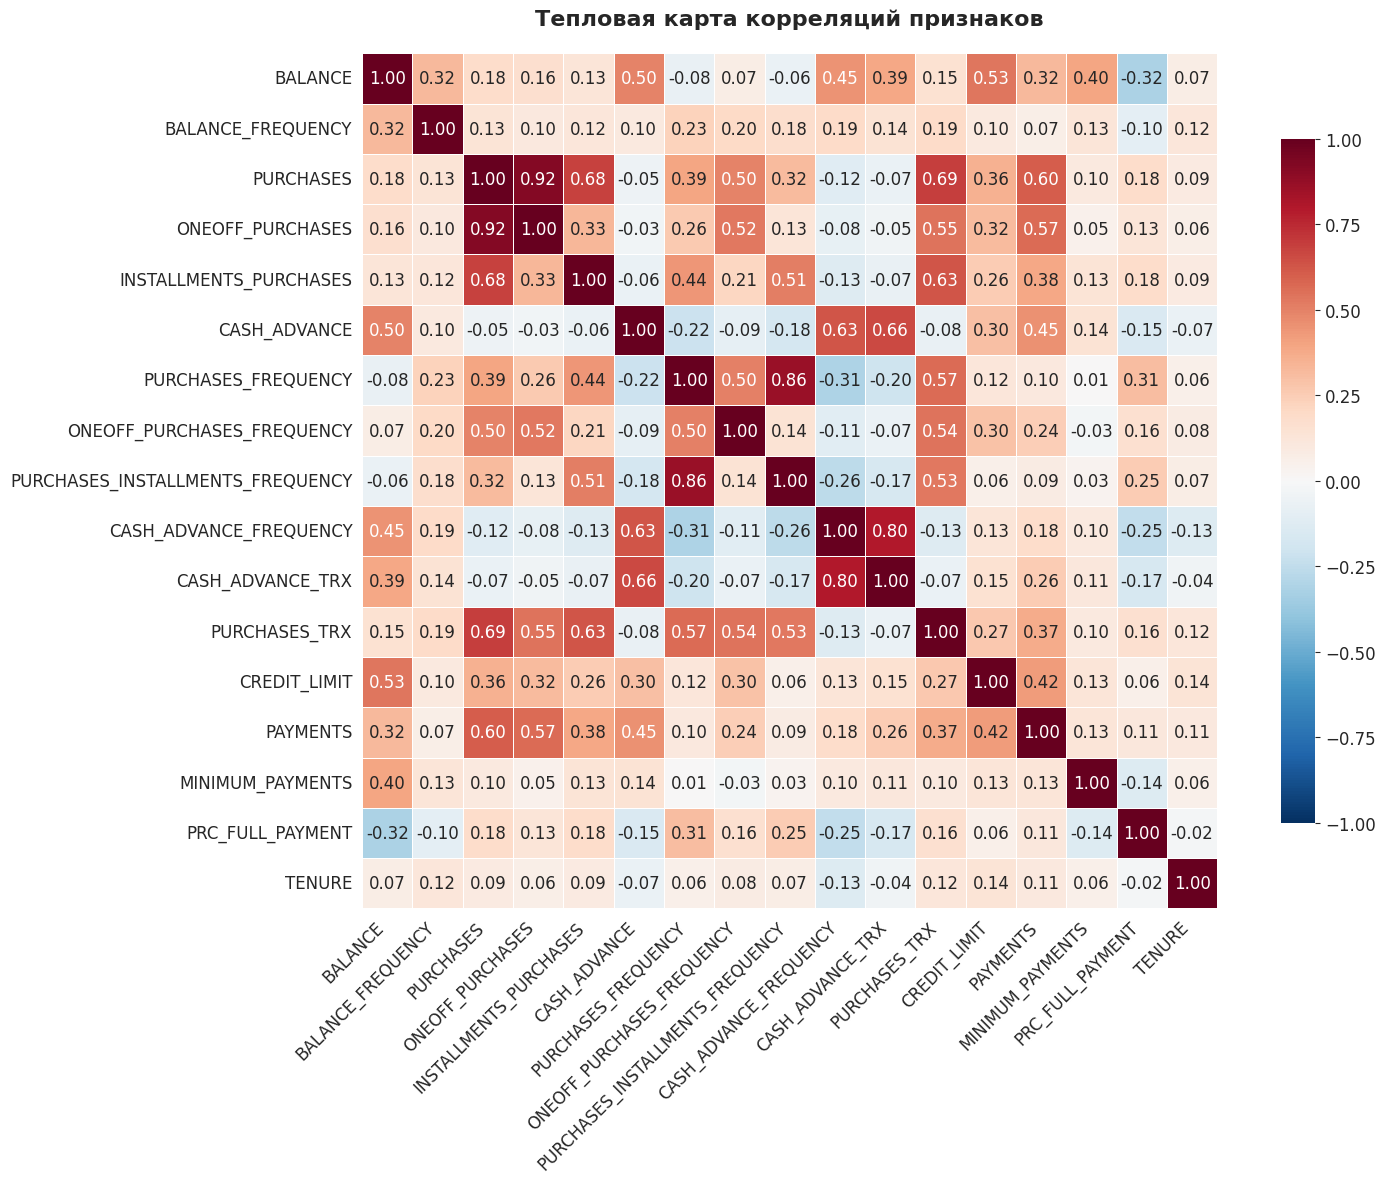

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|r| > 0.7)
  PURCHASES <-> ONEOFF_PURCHASES: 0.9168
  PURCHASES_FREQUENCY <-> PURCHASES_INSTALLMENTS_FREQUENCY: 0.8629
  CASH_ADVANCE_FREQUENCY <-> CASH_ADVANCE_TRX: 0.7996


In [49]:
fig, ax = plt.subplots(figsize=(16, 12))

correlation_matrix = df_clean.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_title('Тепловая карта корреляций признаков', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Сильные корреляции
print("=" * 60)
print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|r| > 0.7)")
print("=" * 60)
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        val = correlation_matrix.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {val:.4f}")

## Подбор гиперпараметров моделей

Поскольку KMeans — алгоритм без учителя, стандартный GridSearchCV неприменим.
Реализуем аналогичный полный перебор параметров с оценкой по внутренним метрикам
кластеризации и усреднением по 3 запускам (аналог cv=3).

Перебор выполняется **отдельно для каждого метода инициализации** (`random` = KMeans,
`k-means++` = KMeans++), чтобы затем сравнить лучшие модели.

In [50]:
param_grid = {
    'n_clusters': [2, 4, 6, 8, 10, 12, 14, 16, 18],
    'init': ['random', 'k-means++'],
    'n_init': [10, 20, 30],
    'algorithm': ['lloyd', 'elkan']
}

all_params = list(ParameterGrid(param_grid))
print("=" * 60)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ (cv=3)")
print("=" * 60)
print(f"\nСетка параметров:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")
print(f"\nОбщее количество комбинаций: {len(all_params)}")
print(f"С учётом cv=3: {len(all_params) * 3} обучений")
print("\nПеребор начат...")

cv = 3
results = []

for idx, params in enumerate(all_params):
    sil_scores, ch_scores, db_scores, inertias, times = [], [], [], [], []

    for seed in range(cv):
        t0 = time.time()
        model = KMeans(
            n_clusters=params['n_clusters'],
            init=params['init'],
            n_init=params['n_init'],
            algorithm=params['algorithm'],
            max_iter=300,
            random_state=seed * 42
        )
        labels = model.fit_predict(X_scaled)
        elapsed = time.time() - t0

        sil_scores.append(silhouette_score(X_scaled, labels))
        ch_scores.append(calinski_harabasz_score(X_scaled, labels))
        db_scores.append(davies_bouldin_score(X_scaled, labels))
        inertias.append(model.inertia_)
        times.append(elapsed)

    results.append({
        'params': params,
        'n_clusters': params['n_clusters'],
        'init': params['init'],
        'n_init': params['n_init'],
        'algorithm': params['algorithm'],
        'max_iter': 300,
        'mean_silhouette': np.mean(sil_scores),
        'std_silhouette': np.std(sil_scores),
        'mean_calinski_harabasz': np.mean(ch_scores),
        'mean_davies_bouldin': np.mean(db_scores),
        'mean_inertia': np.mean(inertias),
        'mean_time': np.mean(times)
    })

    print(f"  Обработано {idx + 1}/{len(all_params)}...")

results_df = pd.DataFrame(results)
print(f"\nПеребор завершён! Обработано {len(all_params)} комбинаций.")

ПОДБОР ГИПЕРПАРАМЕТРОВ (cv=3)

Сетка параметров:
  n_clusters: [2, 4, 6, 8, 10, 12, 14, 16, 18]
  init: ['random', 'k-means++']
  n_init: [10, 20, 30]
  algorithm: ['lloyd', 'elkan']

Общее количество комбинаций: 108
С учётом cv=3: 324 обучений

Перебор начат...
  Обработано 1/108...
  Обработано 2/108...
  Обработано 3/108...
  Обработано 4/108...
  Обработано 5/108...
  Обработано 6/108...
  Обработано 7/108...
  Обработано 8/108...
  Обработано 9/108...
  Обработано 10/108...
  Обработано 11/108...
  Обработано 12/108...
  Обработано 13/108...
  Обработано 14/108...
  Обработано 15/108...
  Обработано 16/108...
  Обработано 17/108...
  Обработано 18/108...
  Обработано 19/108...
  Обработано 20/108...
  Обработано 21/108...
  Обработано 22/108...
  Обработано 23/108...
  Обработано 24/108...
  Обработано 25/108...
  Обработано 26/108...
  Обработано 27/108...
  Обработано 28/108...
  Обработано 29/108...
  Обработано 30/108...
  Обработано 31/108...
  Обработано 32/108...
  Обработа

In [51]:
# Разделение результатов по методам
results_random = results_df[results_df['init'] == 'random'].sort_values(
    'mean_silhouette', ascending=False).reset_index(drop=True)
results_pp = results_df[results_df['init'] == 'k-means++'].sort_values(
    'mean_silhouette', ascending=False).reset_index(drop=True)
results_random.index += 1
results_pp.index += 1

print("=" * 60)
print("ТОП-5 КОМБИНАЦИЙ — KMeans (random init)")
print("=" * 60)
display_cols = ['n_clusters', 'n_init', 'max_iter', 'algorithm',
                'mean_silhouette', 'std_silhouette',
                'mean_calinski_harabasz', 'mean_davies_bouldin', 'mean_time']
print(results_random[display_cols].head(5).to_string())

print("\n" + "=" * 60)
print("ТОП-5 КОМБИНАЦИЙ — KMeans++ (k-means++ init)")
print("=" * 60)
print(results_pp[display_cols].head(5).to_string())

ТОП-5 КОМБИНАЦИЙ — KMeans (random init)
   n_clusters  n_init  max_iter algorithm  mean_silhouette  std_silhouette  mean_calinski_harabasz  mean_davies_bouldin  mean_time
1          10      30       300     lloyd         0.222957        0.000775             1280.974909             1.338139   0.503518
2          10      30       300     elkan         0.222957        0.000775             1280.974909             1.338139   1.344772
3          10      10       300     elkan         0.220878        0.000768             1277.755153             1.367185   0.430396
4          10      10       300     lloyd         0.220878        0.000768             1277.755153             1.367185   0.163429
5          10      20       300     lloyd         0.220788        0.000823             1277.963891             1.366378   0.330366

ТОП-5 КОМБИНАЦИЙ — KMeans++ (k-means++ init)
   n_clusters  n_init  max_iter algorithm  mean_silhouette  std_silhouette  mean_calinski_harabasz  mean_davies_bouldin  mean_ti

## Графики лучших наборов параметров

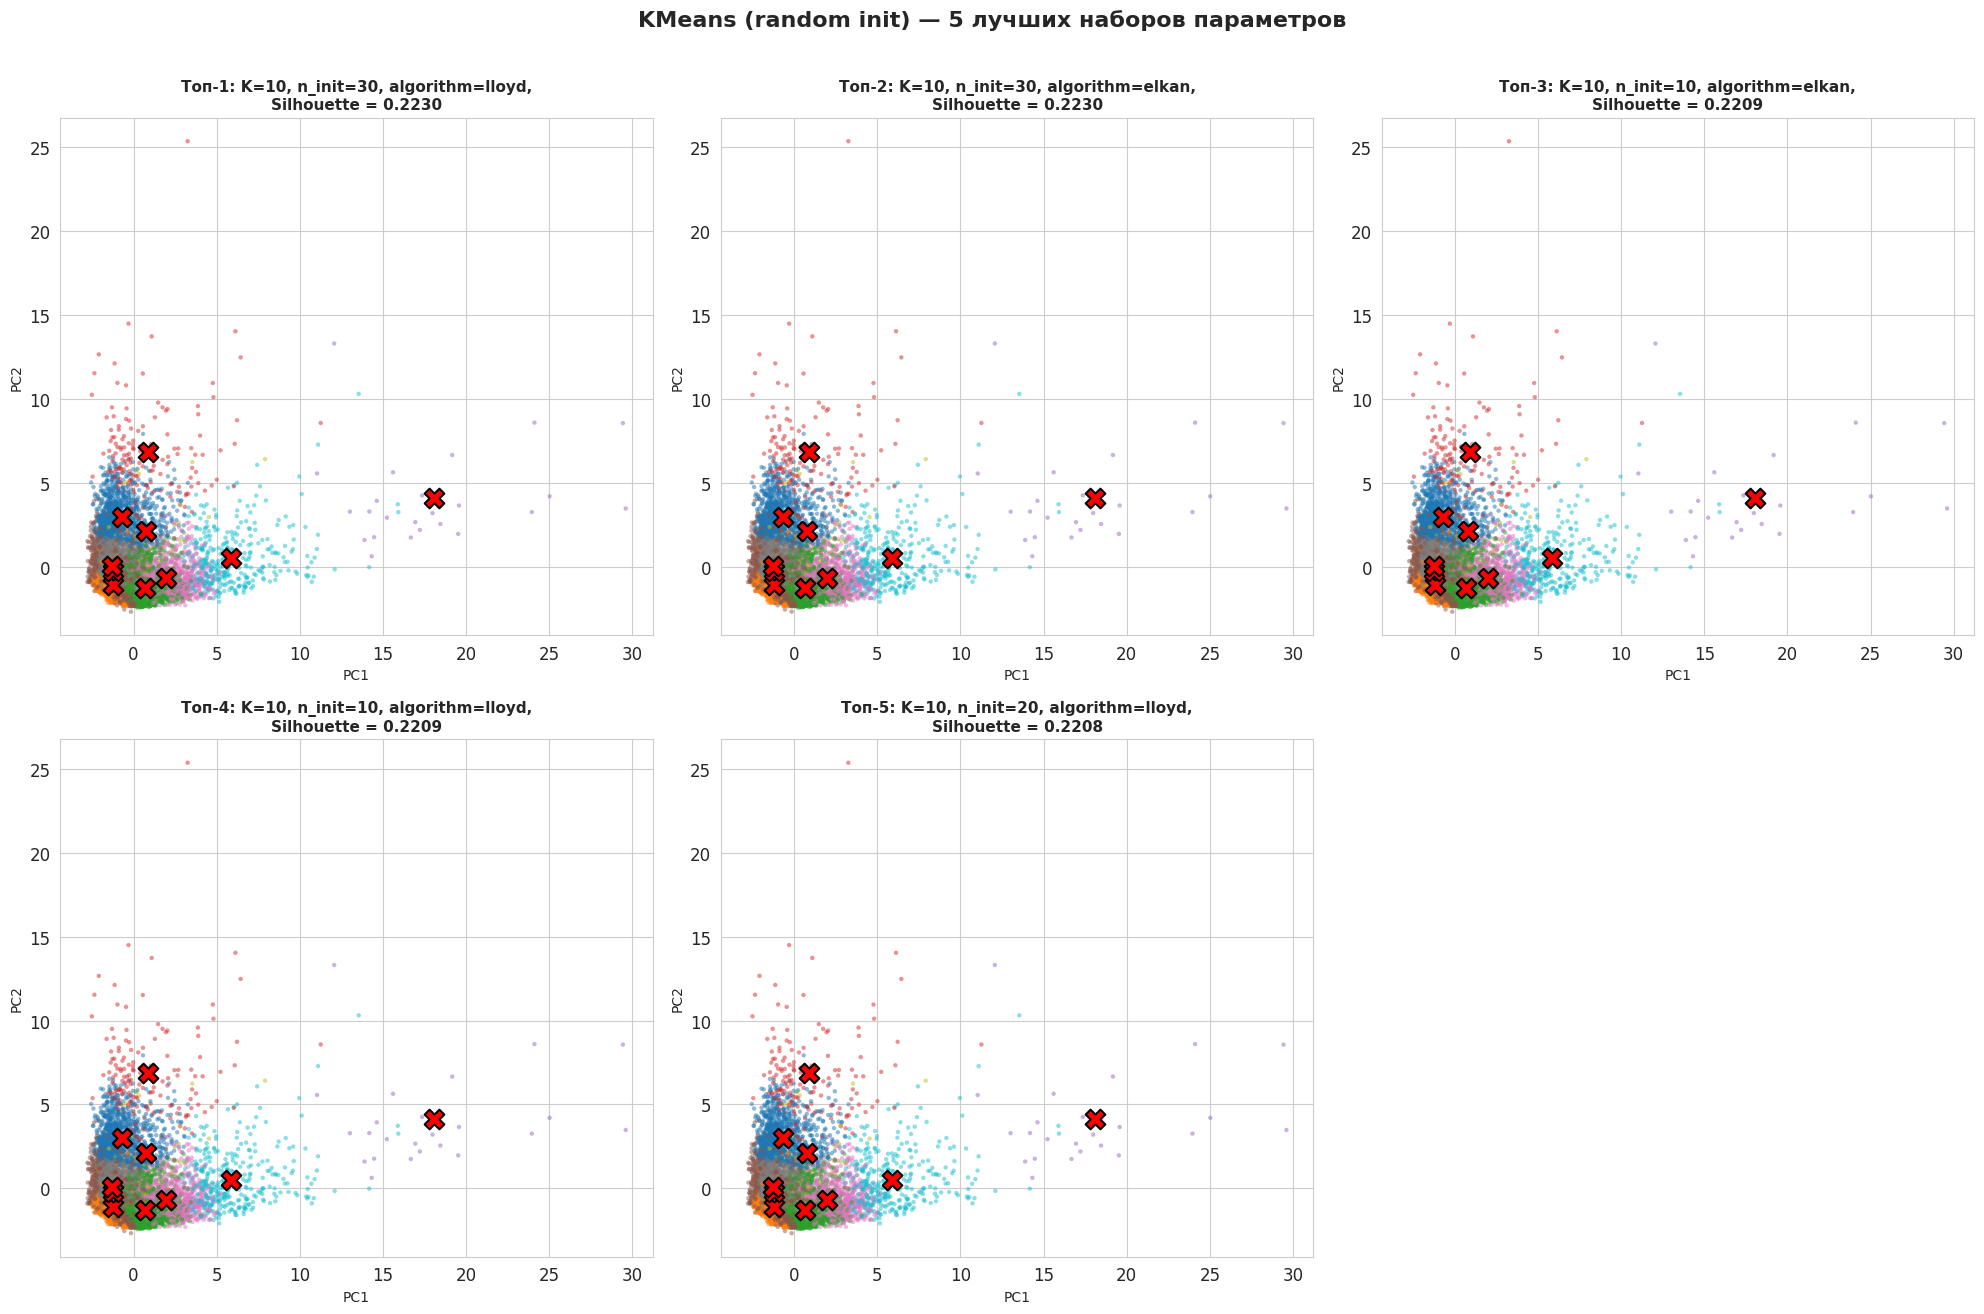

In [52]:
top5_random = results_random.head(5)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for i in range(5):
    row = top5_random.iloc[i]
    p = row['params']

    model = KMeans(n_clusters=p['n_clusters'], init='random', algorithm=p['algorithm'],
                   n_init=p['n_init'], max_iter=300, random_state=42)
    labels = model.fit_predict(X_scaled)
    centroids_pca = pca.transform(model.cluster_centers_)

    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
                    alpha=0.5, s=10, edgecolors='none')
    axes[i].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red',
                    marker='X', s=200, edgecolors='black', linewidths=1.5, zorder=5)

    axes[i].set_title(
        f"Топ-{i+1}: K={p['n_clusters']}, n_init={p['n_init']}, algorithm={p['algorithm']},\n"
        f"Silhouette = {row['mean_silhouette']:.4f}",
        fontsize=11, fontweight='bold')
    axes[i].set_xlabel('PC1', fontsize=10)
    axes[i].set_ylabel('PC2', fontsize=10)

axes[5].axis('off')
plt.suptitle('KMeans (random init) — 5 лучших наборов параметров',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

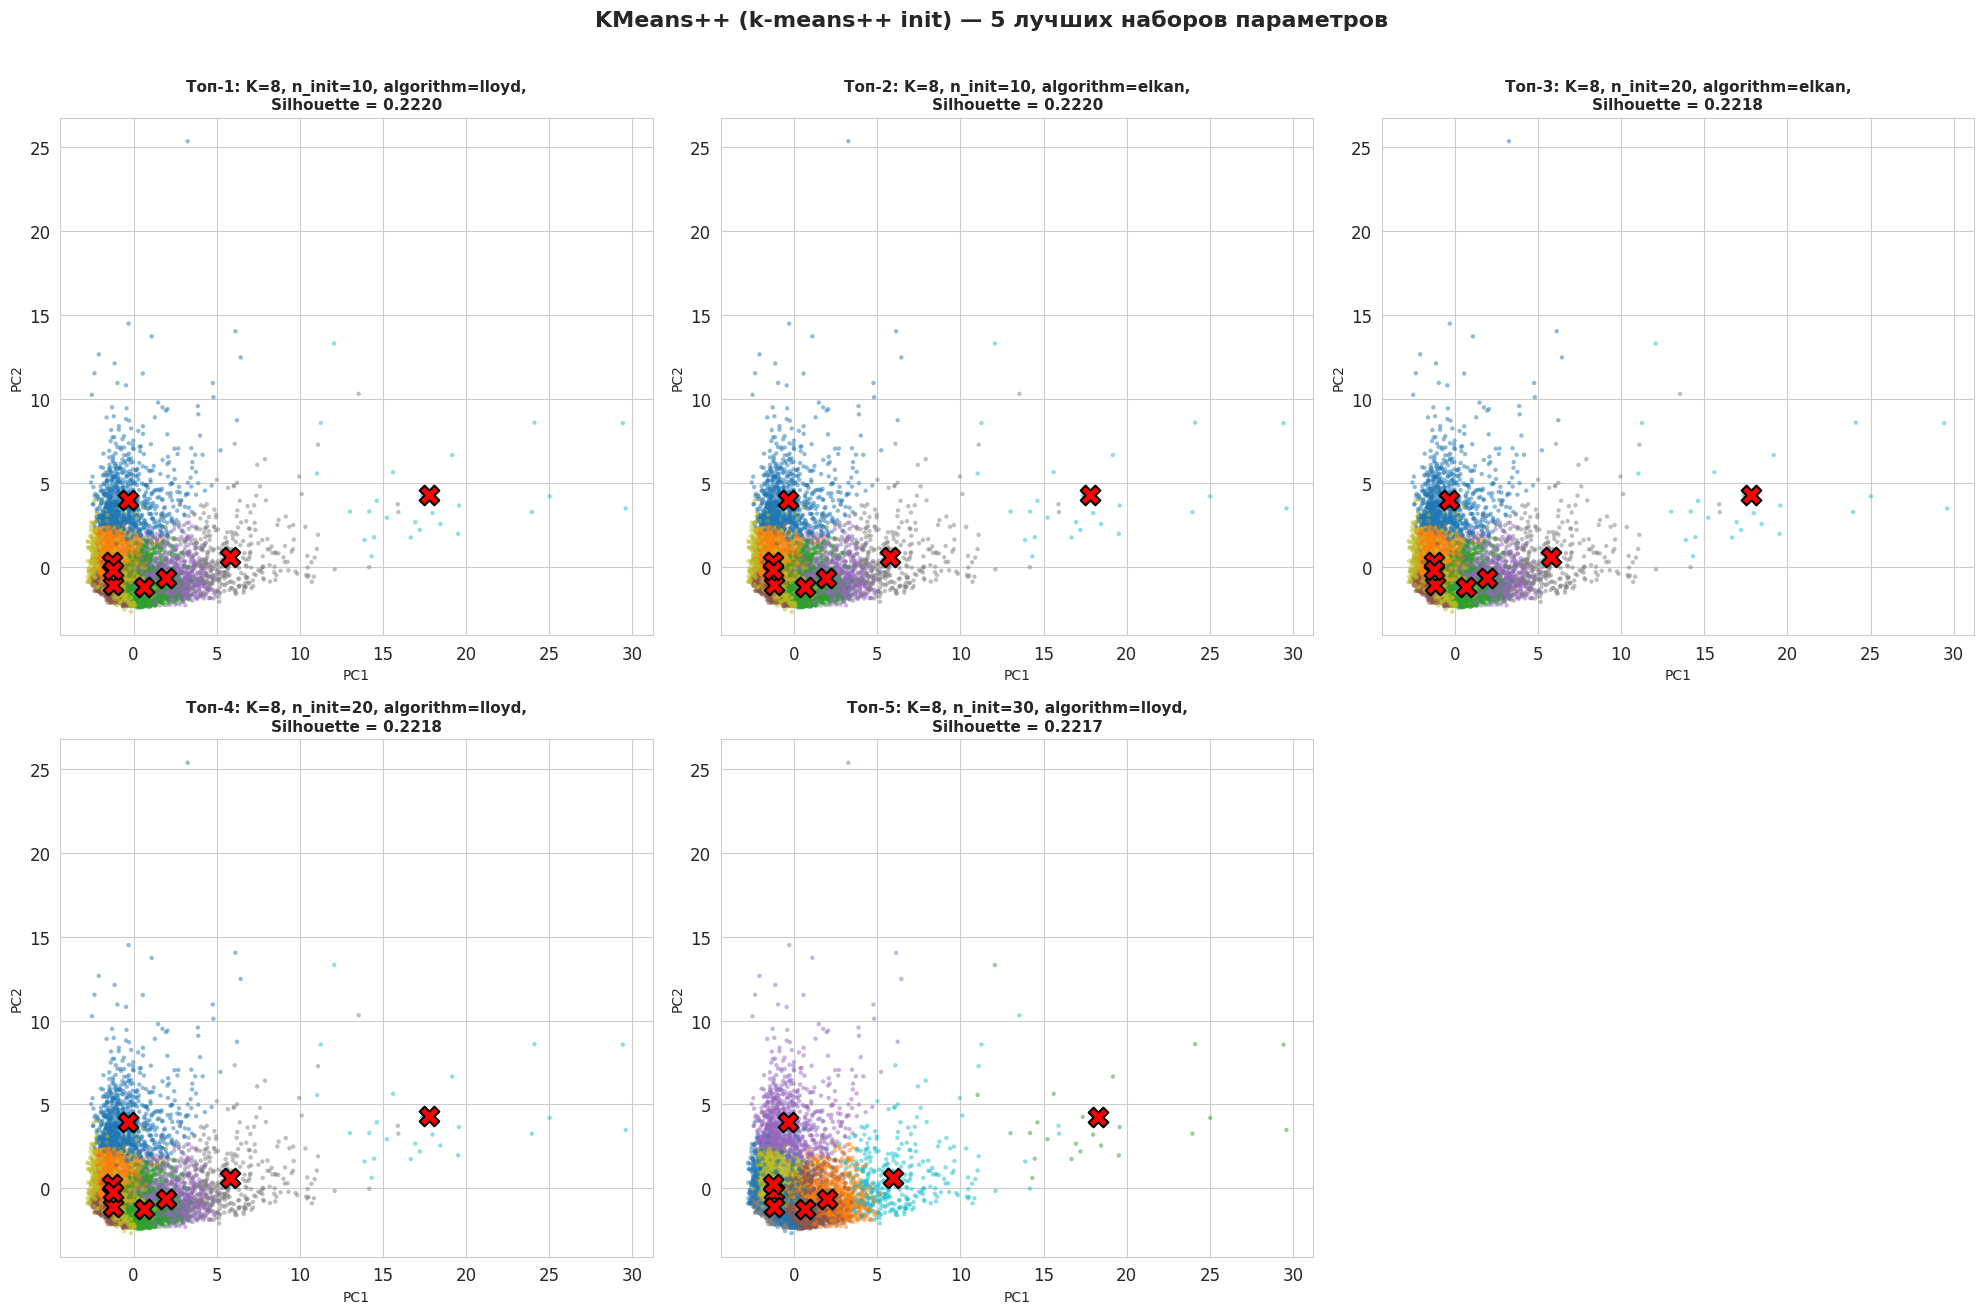

In [53]:
top5_pp = results_pp.head(5)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for i in range(5):
    row = top5_pp.iloc[i]
    p = row['params']

    model = KMeans(n_clusters=p['n_clusters'], init='k-means++', algorithm=p['algorithm'],
                   n_init=p['n_init'], max_iter=300, random_state=42)
    labels = model.fit_predict(X_scaled)
    centroids_pca = pca.transform(model.cluster_centers_)

    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
                    alpha=0.5, s=10, edgecolors='none')
    axes[i].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red',
                    marker='X', s=200, edgecolors='black', linewidths=1.5, zorder=5)

    axes[i].set_title(
        f"Топ-{i+1}: K={p['n_clusters']}, n_init={p['n_init']}, algorithm={p['algorithm']},\n"
        f"Silhouette = {row['mean_silhouette']:.4f}",
        fontsize=11, fontweight='bold')
    axes[i].set_xlabel('PC1', fontsize=10)
    axes[i].set_ylabel('PC2', fontsize=10)

axes[5].axis('off')
plt.suptitle('KMeans++ (k-means++ init) — 5 лучших наборов параметров',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

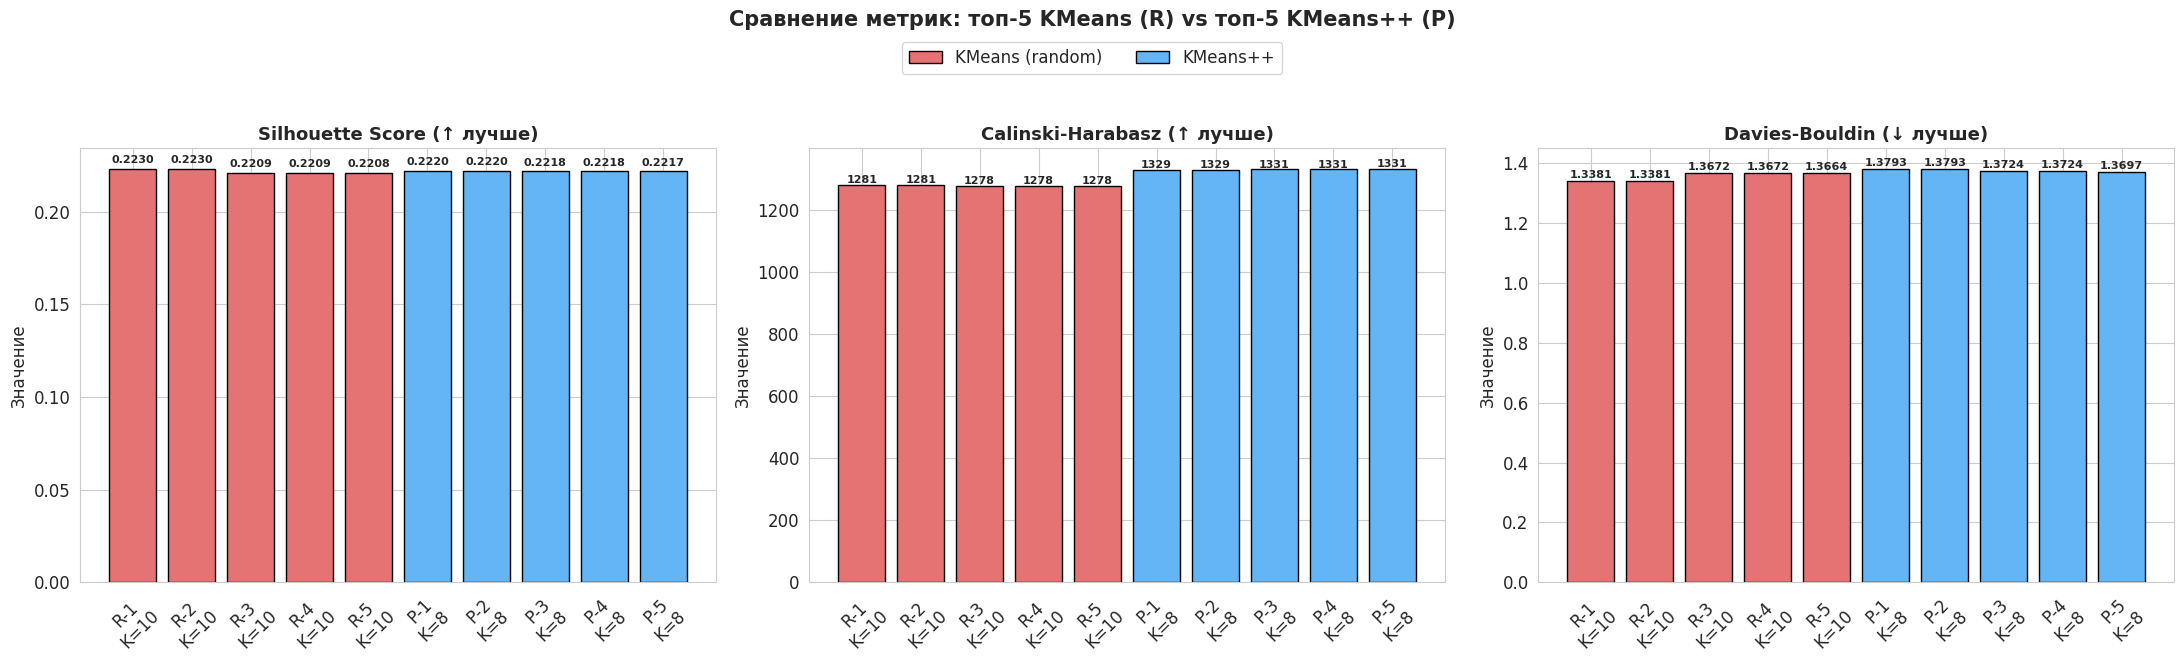

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

labels_r = [f"R-{i+1}\nK={top5_random.iloc[i]['n_clusters']}" for i in range(5)]
labels_p = [f"P-{i+1}\nK={top5_pp.iloc[i]['n_clusters']}" for i in range(5)]
all_labels = labels_r + labels_p
colors_bars = ['#E57373']*5 + ['#64B5F6']*5

# Silhouette
vals = list(top5_random['mean_silhouette']) + list(top5_pp['mean_silhouette'])
bars = axes[0].bar(all_labels, vals, color=colors_bars, edgecolor='black')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Silhouette Score (↑ лучше)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Значение')
axes[0].tick_params(axis='x', rotation=45)

# Calinski-Harabasz
vals = list(top5_random['mean_calinski_harabasz']) + list(top5_pp['mean_calinski_harabasz'])
bars = axes[1].bar(all_labels, vals, color=colors_bars, edgecolor='black')
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Calinski-Harabasz (↑ лучше)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Значение')
axes[1].tick_params(axis='x', rotation=45)

# Davies-Bouldin
vals = list(top5_random['mean_davies_bouldin']) + list(top5_pp['mean_davies_bouldin'])
bars = axes[2].bar(all_labels, vals, color=colors_bars, edgecolor='black')
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
axes[2].set_title('Davies-Bouldin (↓ лучше)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Значение')
axes[2].tick_params(axis='x', rotation=45)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E57373', edgecolor='black', label='KMeans (random)'),
                   Patch(facecolor='#64B5F6', edgecolor='black', label='KMeans++')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, 1.06))
plt.suptitle('Сравнение метрик: топ-5 KMeans (R) vs топ-5 KMeans++ (P)',
             fontsize=15, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

## Обучение моделей

In [55]:
best_random_params = results_random.iloc[0]['params']
best_pp_params = results_pp.iloc[0]['params']

print("=" * 60)
print("ЛУЧШИЕ ПАРАМЕТРЫ")
print("=" * 60)

print("\n--- KMeans (random init) ---")
for k, v in best_random_params.items():
    print(f"  {k}: {v}")

print("\n--- KMeans++ (k-means++ init) ---")
for k, v in best_pp_params.items():
    print(f"  {k}: {v}")

# Обучение KMeans (random)
t0 = time.time()
model_random = KMeans(
    n_clusters=best_random_params['n_clusters'],
    init='random',
    n_init=best_random_params['n_init'],
    algorithm=best_random_params['algorithm'],
    max_iter=300,
    random_state=42
)
labels_random = model_random.fit_predict(X_scaled)
time_random = time.time() - t0

# Обучение KMeans++
t0 = time.time()
model_pp = KMeans(
    n_clusters=best_pp_params['n_clusters'],
    init='k-means++',
    n_init=best_pp_params['n_init'],
    algorithm=best_pp_params['algorithm'],
    max_iter=300,
    random_state=42
)
labels_pp = model_pp.fit_predict(X_scaled)
time_pp = time.time() - t0

print("\nОбе модели обучены!")
print(f"\nKMeans (random):  {time_random:.3f} сек, итераций: {model_random.n_iter_}")
print(f"KMeans++:         {time_pp:.3f} сек, итераций: {model_pp.n_iter_}")

ЛУЧШИЕ ПАРАМЕТРЫ

--- KMeans (random init) ---
  algorithm: lloyd
  init: random
  n_clusters: 10
  n_init: 30

--- KMeans++ (k-means++ init) ---
  algorithm: lloyd
  init: k-means++
  n_clusters: 8
  n_init: 10

Обе модели обучены!

KMeans (random):  0.514 сек, итераций: 78
KMeans++:         0.145 сек, итераций: 14


## Прогнозы моделей

In [56]:
# Добавляем метки в датасет
df_result = df_clean.copy()
df_result['Cluster_Random'] = labels_random
df_result['Cluster_PP'] = labels_pp

print("=" * 60)
print("РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ")
print("=" * 60)

print("\n--- KMeans (random) ---")
for cl, cnt in zip(*np.unique(labels_random, return_counts=True)):
    print(f"  Кластер {cl}: {cnt} ({cnt/len(labels_random)*100:.1f}%)")

print("\n--- KMeans++ ---")
for cl, cnt in zip(*np.unique(labels_pp, return_counts=True)):
    print(f"  Кластер {cl}: {cnt} ({cnt/len(labels_pp)*100:.1f}%)")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 15 ОБЪЕКТОВ С МЕТКАМИ КЛАСТЕРОВ")
print("=" * 60)
df_result[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
           'PAYMENTS', 'Cluster_Random', 'Cluster_PP']].head(15)

РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ

--- KMeans (random) ---
  Кластер 0: 1041 (11.6%)
  Кластер 1: 1172 (13.1%)
  Кластер 2: 1948 (21.8%)
  Кластер 3: 150 (1.7%)
  Кластер 4: 24 (0.3%)
  Кластер 5: 619 (6.9%)
  Кластер 6: 1084 (12.1%)
  Кластер 7: 2516 (28.1%)
  Кластер 8: 44 (0.5%)
  Кластер 9: 352 (3.9%)

--- KMeans++ ---
  Кластер 0: 897 (10.0%)
  Кластер 1: 2740 (30.6%)
  Кластер 2: 2005 (22.4%)
  Кластер 3: 1116 (12.5%)
  Кластер 4: 1179 (13.2%)
  Кластер 5: 364 (4.1%)
  Кластер 6: 624 (7.0%)
  Кластер 7: 25 (0.3%)

ПЕРВЫЕ 15 ОБЪЕКТОВ С МЕТКАМИ КЛАСТЕРОВ


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,Cluster_Random,Cluster_PP
0,40.900749,95.40,0.000000,1000.0,201.802084,7,1
1,3202.467416,0.00,6442.945483,7000.0,4103.032597,0,0
2,2495.148862,773.17,0.000000,7500.0,622.066742,6,3
3,1666.670542,1499.00,205.788017,7500.0,0.000000,7,1
4,817.714335,16.00,0.000000,1200.0,678.334763,7,1
5,1809.828751,1333.28,0.000000,1800.0,1400.057770,2,2
6,627.260806,7091.01,0.000000,13500.0,6354.314328,9,5
7,1823.652743,436.20,0.000000,2300.0,679.065082,2,2
8,1014.926473,861.49,0.000000,7000.0,688.278568,7,1
9,152.225975,1281.60,0.000000,11000.0,1164.770591,1,4


In [57]:
# Профили кластеров — KMeans (random)
print("=" * 60)
print("ПРОФИЛИ КЛАСТЕРОВ — KMeans (random)")
print("=" * 60)
df_result.groupby('Cluster_Random').mean().round(2)

ПРОФИЛИ КЛАСТЕРОВ — KMeans (random)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster_PP
Cluster_Random,,,,,,,,,,,,,,,,,,
0,4508.44,0.97,381.24,241.50,139.85,3557.33,0.25,0.11,0.16,0.45,11.93,5.91,7313.89,2438.44,1595.87,0.02,11.65,0.39
1,103.36,0.37,341.89,203.84,138.31,302.50,0.27,0.07,0.19,0.03,0.66,4.31,3863.94,1148.59,180.59,0.24,11.79,3.99
2,770.71,0.96,942.39,193.88,748.97,202.91,0.90,0.09,0.85,0.04,0.74,19.60,3535.69,1101.17,608.60,0.25,11.86,2.01
3,5307.27,0.95,1173.34,759.83,413.52,10449.33,0.41,0.22,0.30,0.64,29.68,15.29,9637.00,11283.64,2083.19,0.11,11.58,0.17
4,5390.39,0.95,27690.87,21422.88,6267.98,929.69,0.89,0.81,0.70,0.04,1.71,123.38,16333.33,26969.90,3274.88,0.49,11.92,7.00
5,834.00,0.79,386.05,232.91,153.62,1081.30,0.42,0.12,0.28,0.19,3.13,5.16,2418.93,593.38,335.31,0.16,7.22,5.97
6,1234.64,0.97,2177.30,1717.21,460.09,269.75,0.89,0.78,0.44,0.05,0.95,30.38,6057.41,2160.90,470.99,0.29,11.88,3.00
7,1364.06,0.97,253.83,200.55,53.47,593.59,0.16,0.09,0.07,0.13,2.43,2.95,3129.36,928.55,665.50,0.02,11.89,1.03
8,4021.31,0.99,883.18,119.60,763.58,913.23,0.51,0.04,0.47,0.08,2.68,18.41,4242.05,1337.37,25383.09,0.00,11.91,1.84


In [58]:
# Профили кластеров — KMeans++
print("=" * 60)
print("ПРОФИЛИ КЛАСТЕРОВ — KMeans++")
print("=" * 60)
df_result.groupby('Cluster_PP').mean().round(2)

ПРОФИЛИ КЛАСТЕРОВ — KMeans++


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster_Random
Cluster_PP,,,,,,,,,,,,,,,,,,
0,5017.37,0.97,521.56,324.06,197.61,5125.22,0.29,0.14,0.20,0.52,16.20,7.87,8187.52,4003.34,2053.25,0.04,11.62,0.60
1,1576.49,0.97,243.09,193.29,49.97,755.36,0.15,0.09,0.07,0.15,2.97,2.78,3369.17,995.99,824.33,0.02,11.88,6.34
2,801.87,0.96,927.74,190.14,738.05,216.44,0.89,0.09,0.84,0.04,0.79,19.44,3548.11,1109.14,739.47,0.25,11.86,2.10
3,1259.47,0.97,2157.98,1705.73,452.26,282.82,0.88,0.77,0.43,0.05,0.98,30.05,6028.61,2146.66,481.48,0.29,11.88,5.91
4,104.09,0.37,339.88,202.22,137.92,308.80,0.27,0.07,0.19,0.03,0.68,4.28,3857.67,1176.49,181.46,0.24,11.78,1.05
5,3762.44,0.99,6199.77,3533.30,2668.11,669.92,0.96,0.66,0.87,0.08,2.27,91.16,9133.24,5862.76,2567.00,0.22,11.97,8.85
6,869.44,0.80,387.46,236.54,151.41,1120.45,0.41,0.12,0.27,0.20,3.25,5.07,2443.14,596.19,341.56,0.16,7.23,4.92
7,5351.55,0.95,27085.31,21002.02,6083.29,1488.36,0.89,0.81,0.71,0.06,2.40,123.32,16360.00,27159.04,3201.83,0.49,11.92,3.96


## Графики результатов и сравнение моделей

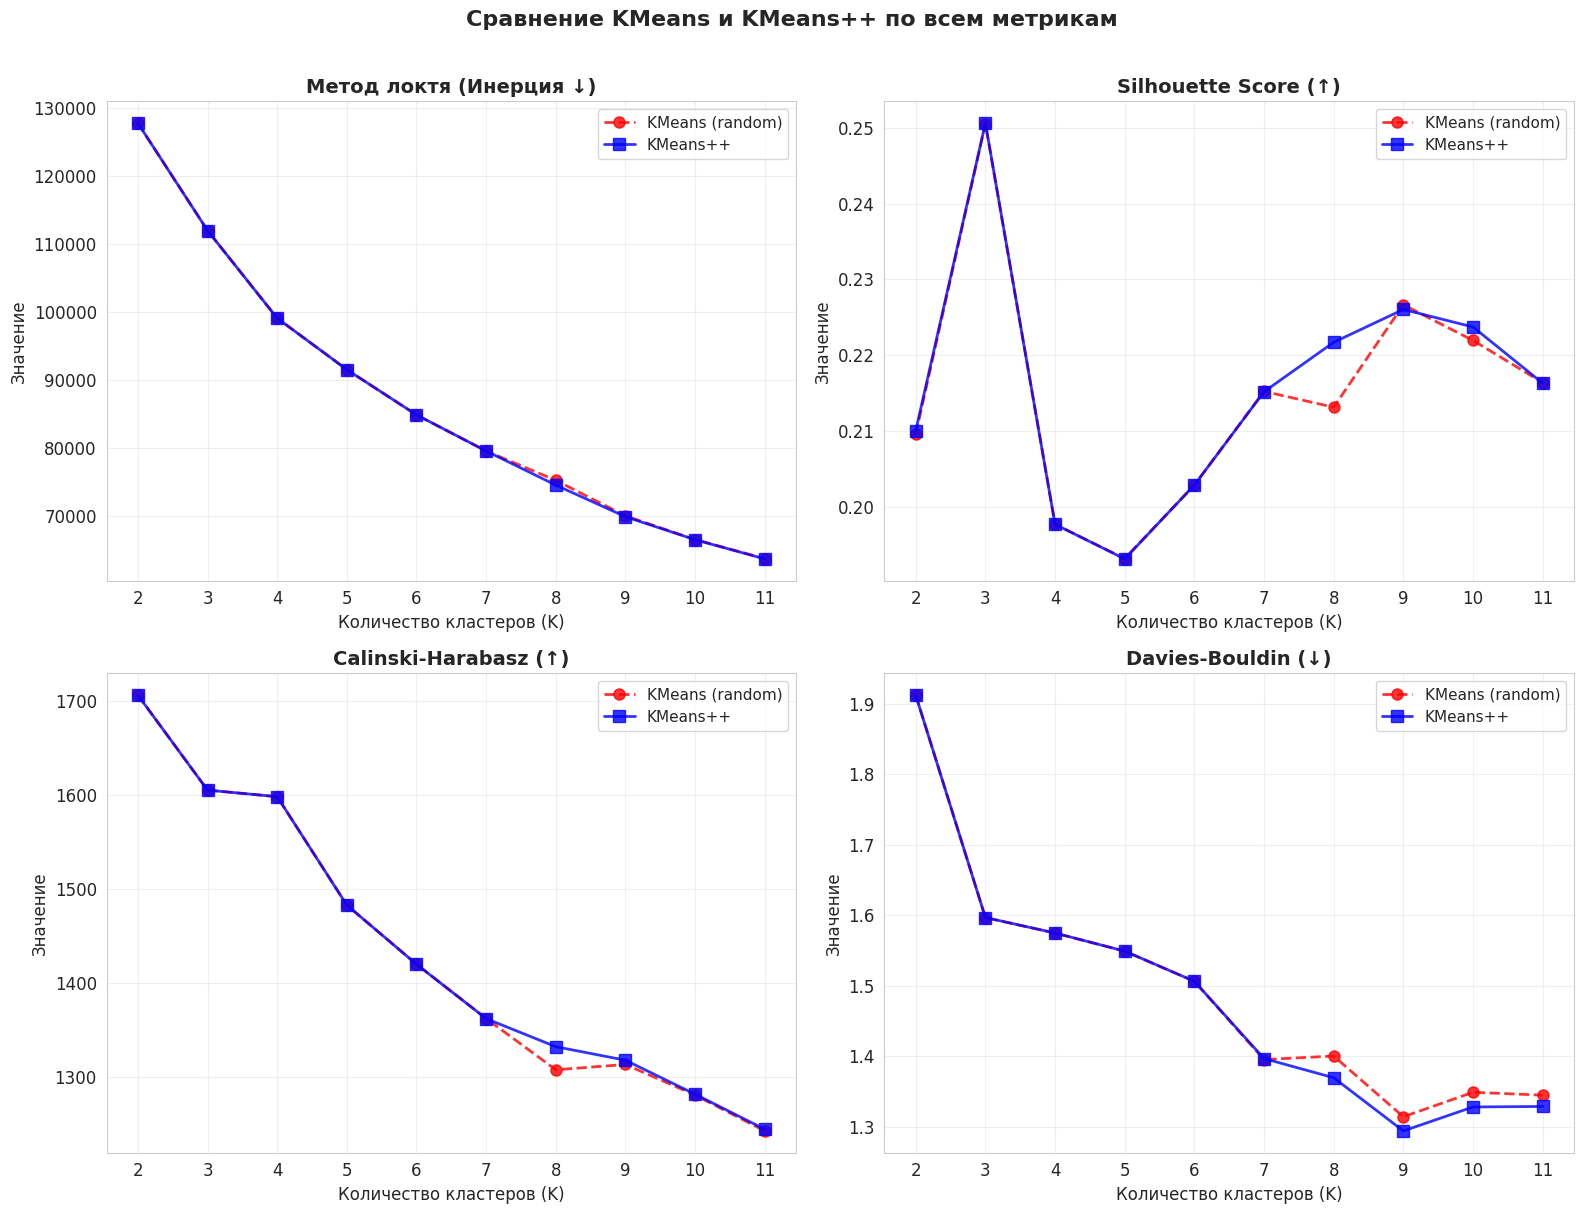

In [59]:
K_range = range(2, 12)
metrics = {'random': {'inertia': [], 'sil': [], 'ch': [], 'db': []},
           'k-means++': {'inertia': [], 'sil': [], 'ch': [], 'db': []}}

for init_method in ['random', 'k-means++']:
    for k in K_range:
        m = KMeans(n_clusters=k, init=init_method, n_init=20, max_iter=500, random_state=42)
        labs = m.fit_predict(X_scaled)
        metrics[init_method]['inertia'].append(m.inertia_)
        metrics[init_method]['sil'].append(silhouette_score(X_scaled, labs))
        metrics[init_method]['ch'].append(calinski_harabasz_score(X_scaled, labs))
        metrics[init_method]['db'].append(davies_bouldin_score(X_scaled, labs))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
titles = ['Метод локтя (Инерция ↓)', 'Silhouette Score (↑)',
          'Calinski-Harabasz (↑)', 'Davies-Bouldin (↓)']
keys = ['inertia', 'sil', 'ch', 'db']
markers = ['o', 's']

for idx, (ax, title, key) in enumerate(zip(axes.flatten(), titles, keys)):
    ax.plot(K_range, metrics['random'][key], 'r--o', lw=2, ms=8,
            label='KMeans (random)', alpha=0.8)
    ax.plot(K_range, metrics['k-means++'][key], 'b-s', lw=2, ms=8,
            label='KMeans++', alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Количество кластеров (K)', fontsize=12)
    ax.set_ylabel('Значение', fontsize=12)
    ax.set_xticks(list(K_range))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение KMeans и KMeans++ по всем метрикам',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

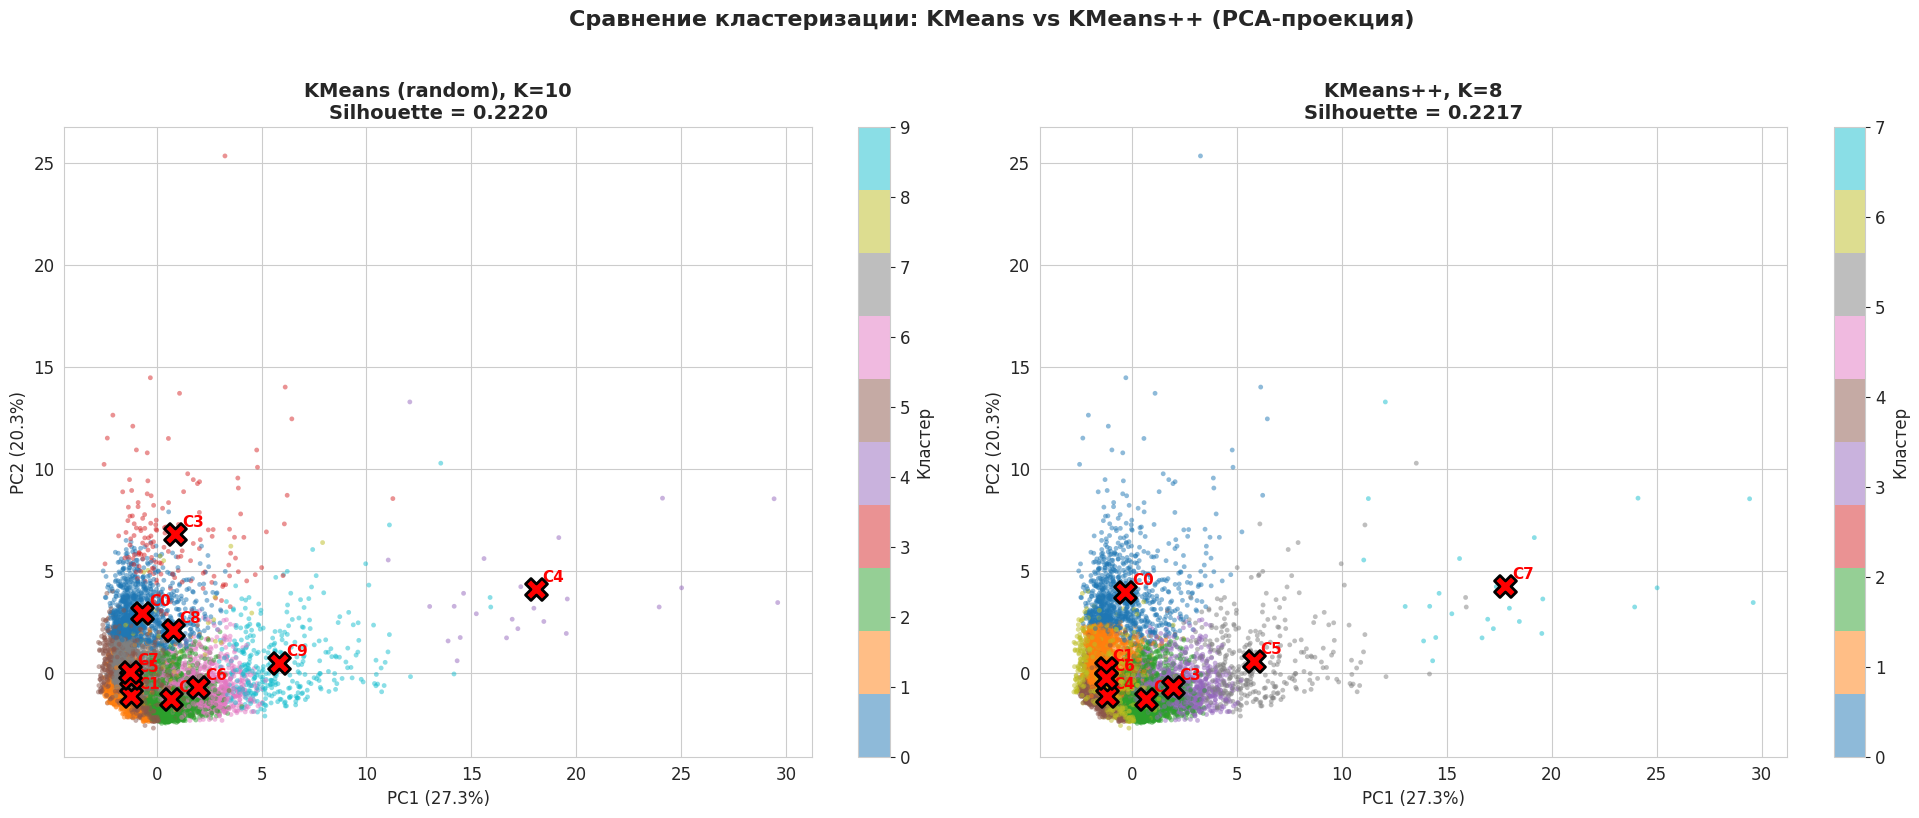

In [60]:
centroids_r_pca = pca.transform(model_random.cluster_centers_)
centroids_p_pca = pca.transform(model_pp.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# KMeans (random)
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_random, cmap='tab10',
                      alpha=0.5, s=12, edgecolors='none')
axes[0].scatter(centroids_r_pca[:, 0], centroids_r_pca[:, 1], c='red',
                marker='X', s=250, edgecolors='black', linewidths=2, zorder=5)
for c in range(best_random_params['n_clusters']):
    axes[0].annotate(f'C{c}', xy=(centroids_r_pca[c, 0], centroids_r_pca[c, 1]),
                     fontsize=11, fontweight='bold', color='red',
                     xytext=(5, 5), textcoords='offset points')
axes[0].set_title(f"KMeans (random), K={best_random_params['n_clusters']}\n"
                  f"Silhouette = {silhouette_score(X_scaled, labels_random):.4f}",
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc1, ax=axes[0], label='Кластер')

# KMeans++
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pp, cmap='tab10',
                      alpha=0.5, s=12, edgecolors='none')
axes[1].scatter(centroids_p_pca[:, 0], centroids_p_pca[:, 1], c='red',
                marker='X', s=250, edgecolors='black', linewidths=2, zorder=5)
for c in range(best_pp_params['n_clusters']):
    axes[1].annotate(f'C{c}', xy=(centroids_p_pca[c, 0], centroids_p_pca[c, 1]),
                     fontsize=11, fontweight='bold', color='red',
                     xytext=(5, 5), textcoords='offset points')
axes[1].set_title(f"KMeans++, K={best_pp_params['n_clusters']}\n"
                  f"Silhouette = {silhouette_score(X_scaled, labels_pp):.4f}",
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc2, ax=axes[1], label='Кластер')

plt.suptitle('Сравнение кластеризации: KMeans vs KMeans++ (PCA-проекция)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

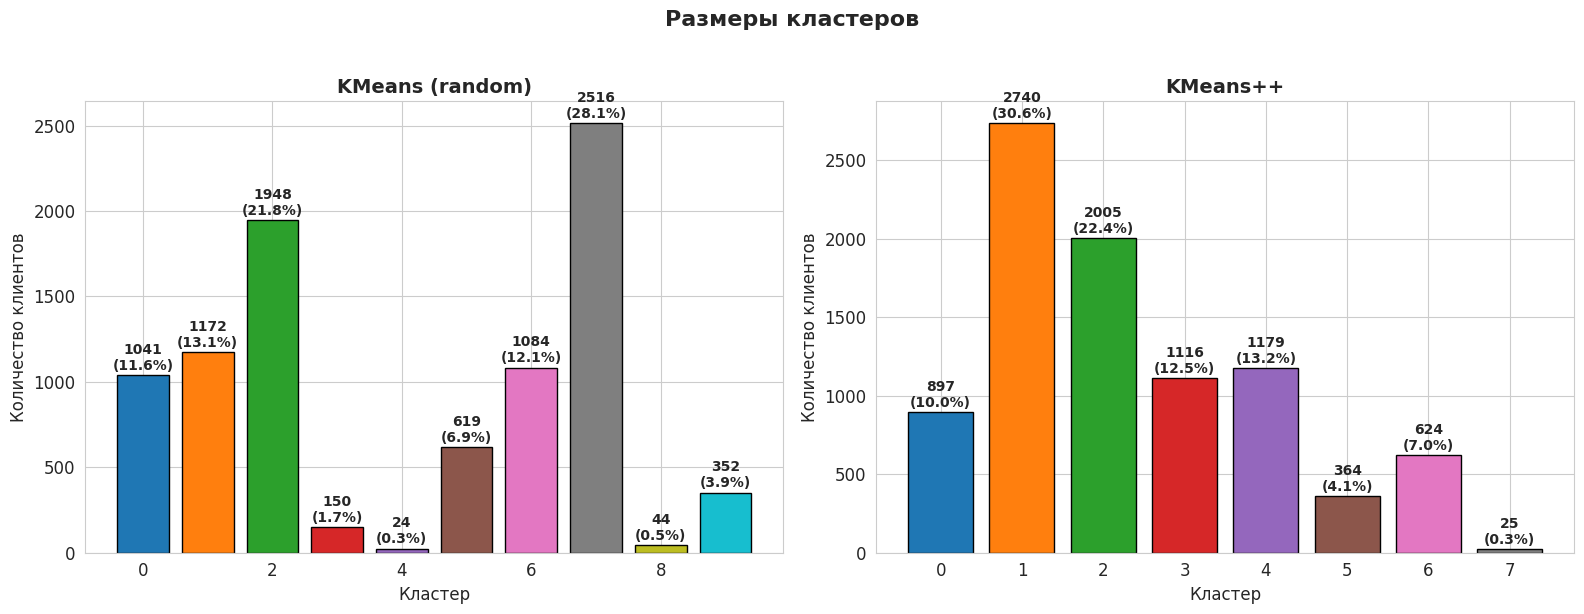

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title in [
    (axes[0], labels_random, 'KMeans (random)'),
    (axes[1], labels_pp, 'KMeans++')
]:
    unique, counts = np.unique(labels, return_counts=True)
    clrs = [plt.cm.tab10(i) for i in range(len(unique))]
    bars = ax.bar(unique, counts, color=clrs, edgecolor='black')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f'{val}\n({val/len(labels)*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'{title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Кластер', fontsize=12)
    ax.set_ylabel('Количество клиентов', fontsize=12)

plt.suptitle('Размеры кластеров', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Интерпретация кластеров

In [62]:
# Берём лучшую модель (KMeans++ или random — ту, что победила)
# Для определённости используем KMeans++
best_labels = labels_pp
best_k = best_pp_params['n_clusters']

df_analysis = df_clean.copy()
df_analysis['Cluster'] = best_labels

print("=" * 70)
print(f"ДЕТАЛЬНЫЕ ПРОФИЛИ КЛАСТЕРОВ (K={best_k}, KMeans++)")
print("=" * 70)

# Средние значения по кластерам
cluster_means = df_analysis.groupby('Cluster').mean()

# Выделим ключевые поведенческие характеристики
key_metrics = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT', 'TENURE'
]

profile = cluster_means[key_metrics].round(2)
profile.index.name = 'Кластер'
profile

ДЕТАЛЬНЫЕ ПРОФИЛИ КЛАСТЕРОВ (K=8, KMeans++)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Кластер,,,,,,,,,,,,
0,5017.37,521.56,324.06,197.61,5125.22,0.29,0.52,8187.52,4003.34,2053.25,0.04,11.62
1,1576.49,243.09,193.29,49.97,755.36,0.15,0.15,3369.17,995.99,824.33,0.02,11.88
2,801.87,927.74,190.14,738.05,216.44,0.89,0.04,3548.11,1109.14,739.47,0.25,11.86
3,1259.47,2157.98,1705.73,452.26,282.82,0.88,0.05,6028.61,2146.66,481.48,0.29,11.88
4,104.09,339.88,202.22,137.92,308.80,0.27,0.03,3857.67,1176.49,181.46,0.24,11.78
5,3762.44,6199.77,3533.30,2668.11,669.92,0.96,0.08,9133.24,5862.76,2567.00,0.22,11.97
6,869.44,387.46,236.54,151.41,1120.45,0.41,0.20,2443.14,596.19,341.56,0.16,7.23
7,5351.55,27085.31,21002.02,6083.29,1488.36,0.89,0.06,16360.00,27159.04,3201.83,0.49,11.92


In [63]:
# Нормализованные профили для наглядного сравнения
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-10)

print("=" * 70)
print("НОРМАЛИЗОВАННЫЕ ПРОФИЛИ (0 = минимум среди кластеров, 1 = максимум)")
print("=" * 70)
profile_norm.round(2)

НОРМАЛИЗОВАННЫЕ ПРОФИЛИ (0 = минимум среди кластеров, 1 = максимум)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Кластер,,,,,,,,,,,,
0,0.94,0.01,0.01,0.02,1.00,0.17,1.00,0.41,0.13,0.62,0.04,0.93
1,0.28,0.00,0.00,0.00,0.11,0.00,0.24,0.07,0.02,0.21,0.00,0.98
2,0.13,0.03,0.00,0.11,0.00,0.91,0.02,0.08,0.02,0.18,0.49,0.98
3,0.22,0.07,0.07,0.07,0.01,0.90,0.04,0.26,0.06,0.10,0.57,0.98
4,0.00,0.00,0.00,0.01,0.02,0.15,0.00,0.10,0.02,0.00,0.47,0.96
5,0.70,0.22,0.16,0.43,0.09,1.00,0.10,0.48,0.20,0.79,0.43,1.00
6,0.15,0.01,0.00,0.02,0.18,0.32,0.35,0.00,0.00,0.05,0.30,0.00
7,1.00,1.00,1.00,1.00,0.26,0.91,0.06,1.00,1.00,1.00,1.00,0.99


In [64]:
# Автоматическая интерпретация на основе ключевых признаков
print("=" * 70)
print("АВТОМАТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ")
print("=" * 70)

segment_names = {}
segment_descriptions = {}
segment_recommendations = {}

for cl in range(best_k):
    row = profile_norm.loc[cl]
    name_parts = []
    desc_parts = []
    rec_parts = []

    # Анализ баланса
    if row['BALANCE'] > 0.7:
        name_parts.append("Высокий баланс")
        desc_parts.append("держат крупные суммы на счёте")
    elif row['BALANCE'] < 0.3:
        name_parts.append("Низкий баланс")
        desc_parts.append("минимальные остатки на счёте")

    # Анализ покупок
    if row['PURCHASES'] > 0.7 and row['PURCHASES_FREQUENCY'] > 0.7:
        name_parts.append("Активные покупатели")
        desc_parts.append("часто и много покупают")
        rec_parts.append("программы лояльности, кэшбэк на покупки")
    elif row['PURCHASES'] < 0.2 and row['PURCHASES_FREQUENCY'] < 0.3:
        desc_parts.append("редко совершают покупки")
        rec_parts.append("стимулирование первых покупок, приветственные бонусы")

    # Анализ разовых vs рассрочка
    if row['ONEOFF_PURCHASES'] > 0.7:
        desc_parts.append("предпочитают крупные разовые покупки")
        rec_parts.append("предложения на премиальные товары")
    if row['INSTALLMENTS_PURCHASES'] > 0.7:
        desc_parts.append("активно пользуются рассрочкой")
        rec_parts.append("выгодные условия рассрочки, партнёрские программы")

    # Анализ снятия наличных
    if row['CASH_ADVANCE'] > 0.7 and row['CASH_ADVANCE_FREQUENCY'] > 0.7:
        name_parts.append("Снятие наличных")
        desc_parts.append("часто снимают наличные (возможно, финансовые трудности)")
        rec_parts.append("реструктуризация долга, финансовое консультирование")
    elif row['CASH_ADVANCE'] > 0.5:
        desc_parts.append("периодически снимают наличные")

    # Анализ платежей
    if row['PRC_FULL_PAYMENT'] > 0.7:
        name_parts.append("Дисциплинированные")
        desc_parts.append("погашают задолженность полностью")
        rec_parts.append("повышение кредитного лимита, премиальные карты")
    elif row['PRC_FULL_PAYMENT'] < 0.2:
        desc_parts.append("редко погашают полностью")
        rec_parts.append("напоминания о платежах, реструктуризация")

    # Кредитный лимит
    if row['CREDIT_LIMIT'] > 0.7:
        name_parts.append("Премиум")
        desc_parts.append("высокий кредитный лимит")
    elif row['CREDIT_LIMIT'] < 0.2:
        desc_parts.append("низкий кредитный лимит")

    # Формируем итоговое название
    if not name_parts:
        name_parts.append("Умеренные пользователи")

    segment_names[cl] = " / ".join(name_parts)
    segment_descriptions[cl] = "; ".join(desc_parts) if desc_parts else "средние показатели по всем метрикам"
    segment_recommendations[cl] = "; ".join(rec_parts) if rec_parts else "стандартные предложения, мониторинг активности"

# Вывод
for cl in range(best_k):
    count = (best_labels == cl).sum()
    pct = count / len(best_labels) * 100
    print(f"\n{'─' * 70}")
    print(f"  КЛАСТЕР {cl}: «{segment_names[cl]}»")
    print(f"  Размер: {count} клиентов ({pct:.1f}%)")
    print(f"{'─' * 70}")
    print(f"  Характеристика: {segment_descriptions[cl]}")
    print(f"  Рекомендации:   {segment_recommendations[cl]}")

АВТОМАТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ

──────────────────────────────────────────────────────────────────────
  КЛАСТЕР 0: «Высокий баланс / Снятие наличных»
  Размер: 897 клиентов (10.0%)
──────────────────────────────────────────────────────────────────────
  Характеристика: держат крупные суммы на счёте; редко совершают покупки; часто снимают наличные (возможно, финансовые трудности); редко погашают полностью
  Рекомендации:   стимулирование первых покупок, приветственные бонусы; реструктуризация долга, финансовое консультирование; напоминания о платежах, реструктуризация

──────────────────────────────────────────────────────────────────────
  КЛАСТЕР 1: «Низкий баланс»
  Размер: 2740 клиентов (30.6%)
──────────────────────────────────────────────────────────────────────
  Характеристика: минимальные остатки на счёте; редко совершают покупки; редко погашают полностью; низкий кредитный лимит
  Рекомендации:   стимулирование первых покупок, приветственные бонусы; напоминания о плате